# Entraînement d'un modèle Unet++ pour la segmentation de bâtiments en utilisant le package GDL

Ce tutoriel nous guide à travers un **flux de travail minimal de bout en bout** pour entraîner un modèle de segmentation sémantique sur des rasters géospatiaux en utilisant le package GDL. Vous pouvez adapter ce flux de travail à vos propres données et configurations.

1) préparer un petit jeu de données,
2) entraîner **UNet++**,
3) exécuter l'inférence / le test,
4) visualiser les prédictions.

## Préparation de l'environnement Python

Pour commencer, nous devons installer le package GDL dans notre environnement. Nous le ferons en tant que développeur ; c'est-à-dire que nous apporterons plus tard des modifications aux fonctions sources du package pour mieux l'adapter à notre jeu de données/problème. Nous supposerons que nous avons déjà créé un environnement "tutorial" en utilisant les fichiers de requirements disponibles à la racine de ce dépôt.
- [Si vous avez un GPU disponible sur votre appareil](https://github.com/geoaiclassroom/geoai_learning/blob/main/requirements_gpu.txt)
- [Si vous n'avez que le CPU disponible sur votre appareil](https://github.com/geoaiclassroom/geoai_learning/blob/main/requirements_cpu.txt)

Ensuite, nous devons ajouter GDL à cet environnement.

Pour ce faire, clonez d'abord la branche principale de GDL sur votre machine :

    git clone https://github.com/NRCan/geo-deep-learning.git

Ensuite, activez votre environnement "tutorial" (*conda activate tutorial*) et entrez (*cd*) dans le répertoire cloné (*geo-deep-learning*). Remplacez le fichier "pyproject.toml" existant par [celui disponible dans ce tutoriel](/GDL_edits/pyproject.toml). J'ai apporté des modifications minimales à ce fichier pyproject en supprimant certaines dépendances strictes sur la version de torch étant donné que nous avons déjà une version torch compatible installée dans notre environnement tutorial.

Ensuite, installez le package :

    pip install -e .

Pour vérifier si l'installation a réussi :

    conda list geo-deep-learning

Cela devrait montrer que la version 0.1.1 de geo-deep-learning est disponible. Nous sommes maintenant prêts à suivre ce tutoriel !

## Source du jeu de données

Dans ce tutoriel, nous utilisons un petit sous-ensemble du **Waterloo Building Dataset**. Ce jeu de données se compose d'orthoimagerie aérienne haute résolution et d'étiquettes de contours de bâtiments, introduit dans l'article :

>Hongjie He, Zijian Jiang, Gao, Kyle, Sarah Narges Fatholahi, Weikai Tan, Bingxu Hu, Hongzhang Xu, Michael A Chapman, and Jonathan Li. Waterloo building dataset: A city-scale vector building dataset for mapping building footprints using aerial orthoimagery. Geomatica, 75(3):99–115, 2022d

Le jeu de données est ouvertement accessible via **Harvard Dataverse** :  
[https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/EXRA2V](https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/EXRA2V)

Pour la reproductibilité et un tutoriel léger, nous fournissons un [sous-ensemble pré-échantillonné du jeu de données](/Data/waterloo_subset_512.zip) dans ce dépôt.

In [1]:
import csv
import platform
import sys
import warnings
from tqdm import TqdmWarning
warnings.filterwarnings("ignore", category=TqdmWarning)
import zipfile
from pathlib import Path

import lightning as L
import matplotlib.pyplot as plt
import numpy as np
import rasterio as rio
import torch
from PIL import Image

# Supprimer les avertissements des jeux de données non géoréférencés (applicable à cet exemple puisque l'imagerie n'est pas géoréférencée)
from rasterio.errors import NotGeoreferencedWarning
warnings.filterwarnings("ignore", category=NotGeoreferencedWarning)

# Afficher les informations système
print("\n--- Environment Info ---")
print("Python:", sys.version.split()[0])
print("OS:", platform.platform())
print("Torch:", torch.__version__)
print("Lightning:", L.__version__)
print("Device:", "CUDA" if torch.cuda.is_available() else "CPU")


--- Environment Info ---
Python: 3.12.13
OS: Windows-11-10.0.22631-SP0
Torch: 2.10.0+cu126
Lightning: 2.6.1
Device: CUDA


## Préparer le jeu de données

L'étape suivante va :

1. **Décompresser** l'archive de démonstration dans un dossier à côté du fichier `.zip`  
2. **Prévisualiser** une paire image-étiquette exemple pour une vérification rapide  
   
**Note** : Dans ce sous-ensemble, les images et étiquettes sont **déjà divisées en patches 512×512**. Dans un flux de travail réel, vous pourriez commencer avec une imagerie pleine scène et des rasters/vecteurs d'étiquettes correspondants. Dans ce cas, vous devrez d'abord **les découper en petites tuiles** (par ex., 256×256 ou 512×512) avant l'entraînement.

Data\waterloo_subset_512 already extracted.


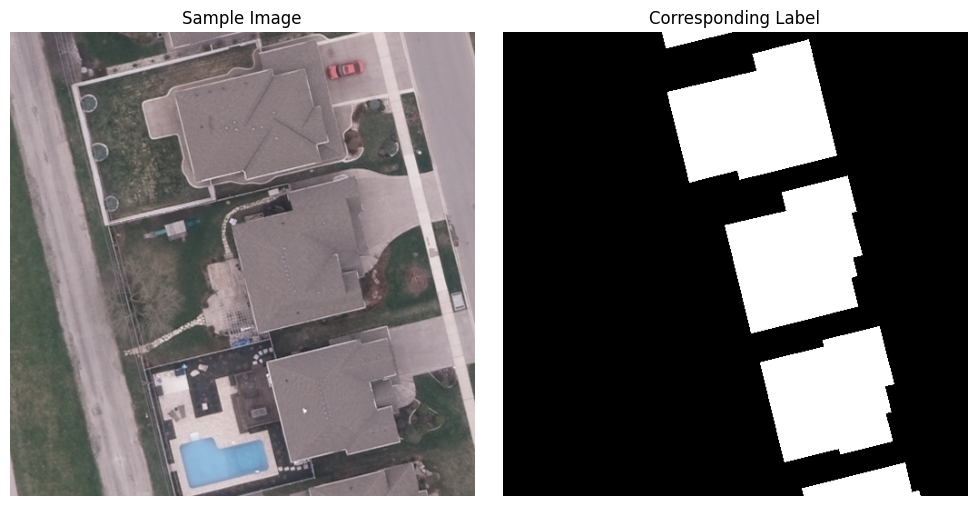

In [2]:
# Définir le chemin vers l'archive et l'emplacement d'extraction
zip_path = Path("./Data/waterloo_subset_512.zip")
extract_dir = zip_path.with_suffix("")  # supprime .zip

# Décompresser uniquement si ce n'est pas déjà fait
if not extract_dir.exists():
    print(f"Extracting to {extract_dir}...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)
else:
    print(f"{extract_dir} already extracted.")

# Vérification : afficher 1 paire image/étiquette de la division 'trn'
img_dir = extract_dir / "trn" / "image"
lbl_dir = extract_dir / "trn" / "label"

sample_imgs = sorted(img_dir.glob("*.tif"))
if sample_imgs:
    sample_path = sample_imgs[0]
    label_path = lbl_dir / sample_path.name

    with rio.open(sample_path) as img_ds:
        img = img_ds.read([1, 2, 3])  # RGB
    with rio.open(label_path) as lbl_ds:
        lbl = lbl_ds.read(1)  # étiquette mono-canal

    # Tracer
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    ax1.imshow(img.transpose(1, 2, 0).astype("uint8"))
    ax1.set_title("Sample Image")
    ax1.axis("off")

    ax2.imshow(lbl, cmap="gray")
    ax2.set_title("Corresponding Label")
    ax2.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No images found in trn/image/")

## Préparer le jeu de données - Créer des fichiers CSV pour chaque division

Nous devons créer un fichier CSV pour chaque division de données qui **associe les paires image-étiquette**.

Cette étape va :

1. Créer 'trn.csv', 'val.csv', et 'tst.csv' à la racine du dossier du jeu de données extrait
2. Chaque CSV listera les chemins absolus vers les patches d'image et d'étiquette, correspondant à la structure attendue par le module CSVDataset de GDL.

In [3]:
splits = ["trn", "val", "tst"]

for split in splits:
    img_dir = extract_dir / split / "image"
    lbl_dir = extract_dir / split / "label"
    csv_path = extract_dir / f"{split}.csv"

    # Collecter les paires image-étiquette correspondantes
    rows = []
    for img_path in sorted(img_dir.glob("*.tif")):
        lbl_path = lbl_dir / img_path.name
        if lbl_path.exists():
            rows.append([str(img_path.resolve()), str(lbl_path.resolve())])
        else:
            print(f"No matching label found for {img_path.name}")

    # Écrire le CSV
    with csv_path.open("w", newline="") as f:
        writer = csv.writer(f, delimiter=";")
        writer.writerows(rows)

    print(f"Wrote {len(rows)} pairs to {csv_path.name}")

Wrote 32 pairs to trn.csv
Wrote 8 pairs to val.csv
Wrote 8 pairs to tst.csv


## Charger le jeu de données en utilisant CSVDataset et CSVDataModule

L'étape suivante va :

1. Initialiser le `CSVDataModule` de GDL avec la taille de batch, les valeurs de normalisation, et les chemins
2. Appeler `.setup()` pour préparer le `train_dataset`, `val_dataset` et `test_dataset`
3. Utiliser `CSVDataset` directement pour charger un échantillon unique et vérifier que tout fonctionne

### Adaptation 

Les masques de ce jeu de données sont particuliers. Ils ont la valeur 255 pour les bâtiments et 0 pour l'arrière-plan. Dans le pipeline GDL, les étiquettes de classe doivent être consécutives avec 0 réservé pour l'arrière-plan. Nous devons donc convertir les valeurs de masque 255 en 1. De plus, ce jeu de données est "mono-étiquette", ce qui signifie que chaque pixel peut obtenir maximum une étiquette parmi les classes possibles. Nous devons donc lire les masques comme un tableau "sans bande". À ce titre, nous devons adapter le CSVDataModule de GDL à nos besoins.

À cette fin, j'ai créé des overrides qui intègrent en toute sécurité ces caractéristiques spéciales de notre jeu de données. Tout ce que nous devons faire maintenant est de remplacer les fichiers GDL originaux par ceux-ci :

- Copiez le [csv_datamodule.py](/GDL_edits/csv_datamodule.py) de remplacement dans le répertoire cloné sous : le sous-répertoire *geo-deep-learning/geo_deep_learning/datamodules*. Cela remplacera le fichier csv_datamodule.py original.
- Copiez le [csv_dataset.py](/GDL_edits/csv_dataset.py) de remplacement dans le répertoire cloné sous : le sous-répertoire *geo-deep-learning/geo_deep_learning/datasets*. Cela remplacera le fichier csv_dataset.py original.

De plus, étant donné que notre version de torch est différente de celle d'origine utilisée pour développer GDL, nous devons apporter quelques petites modifications aux fonctions principales :
- Copiez le [segmentation_unetplus.py](/GDL_edits/segmentation_unetplus.py) de remplacement dans le répertoire cloné sous : le sous-répertoire *geo-deep-learning/geo_deep_learning/tasks_with_models*. Cela remplacera le fichier segmentation_unetplus.py original.

In [4]:
from geo_deep_learning.datamodules.csv_datamodule import CSVDataModule
from geo_deep_learning.datasets.csv_dataset import CSVDataset

# Valeurs de normalisation (statistiques RGB aléatoires pour la démo ; pour un véritable jeu de données d'entraînement, nous devons les ajuster pour correspondre à nos données)
mean = [0.5, 0.5, 0.5]
std = [0.2, 0.2, 0.2]

# Initialiser le DataModule (Notez les deux derniers arguments que nous avons ajoutés pendant la phase d'adaptation)
dm = CSVDataModule(
    batch_size=4,
    num_workers=1,
    mean=mean,
    std=std,
    csv_root_folder=str(extract_dir),
    patches_root_folder=str(extract_dir),
    single_label=True,
    convert_255_to_1_mask=True
)

dm.setup()

# Tester un échantillon pour vérification
sample = dm.train_dataset[0]
print("Image shape:", sample["image"].shape)
print("Mask shape:", sample["mask"].shape)

Image shape: torch.Size([3, 512, 512])
Mask shape: torch.Size([512, 512])


## Visualiser des échantillons du jeu de données

Avant l'entraînement, il est souvent utile d'**inspecter quelques paires image-étiquette** :  

- confirmer que les patches d'image sont correctement alignés avec leurs étiquettes  
- vérifier la normalisation / l'étirement de contraste utilisé pour le tracé  
- vérifier les valeurs d'étiquette (0 = arrière-plan, 1 = bâtiment dans cette démo)  

Cette visualisation n'affecte pas l'entraînement, mais c'est une bonne habitude pour repérer tôt les problèmes potentiels du jeu de données.

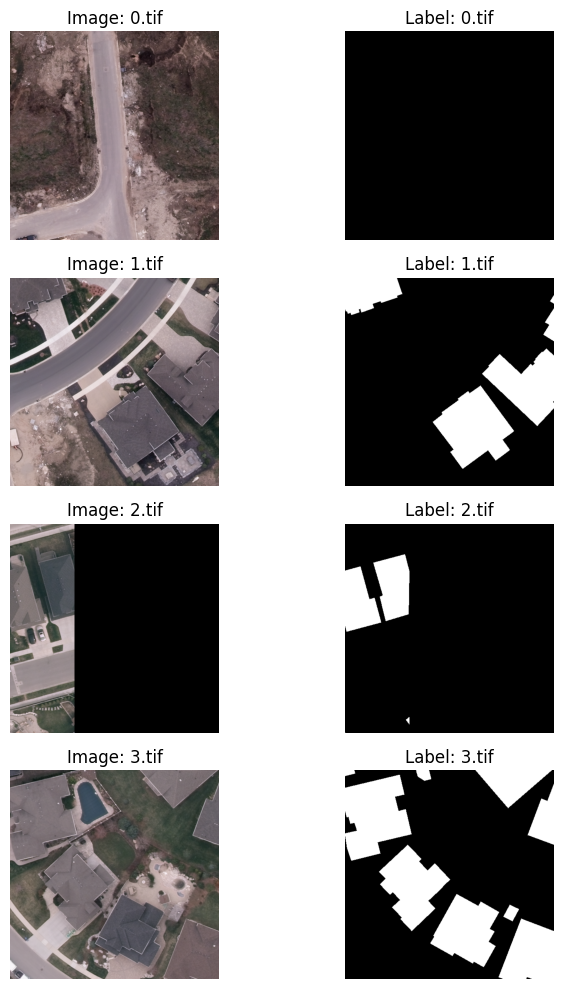

In [5]:
# Combien d'échantillons à afficher
num_samples = 4
samples = dm.val_dataset.files[:num_samples]

fig, axes = plt.subplots(num_samples, 2, figsize=(8, 2.5 * num_samples))

for idx, pair in enumerate(samples):
    img_path = pair["image"]
    lbl_path = pair["mask"]

    # Charger l'image
    with rio.open(img_path) as img_ds:
        image_np = img_ds.read().transpose(1, 2, 0).astype(np.float32)
        image_np = (image_np - image_np.min()) / (image_np.max() - image_np.min())

    # Charger l'étiquette
    with rio.open(lbl_path) as lbl_ds:
        label_np = lbl_ds.read(1)

    # Tracer l'image
    axes[idx, 0].imshow(image_np)
    axes[idx, 0].set_title(f"Image: {img_path.name}")
    axes[idx, 0].axis("off")

    # Tracer l'étiquette
    axes[idx, 1].imshow(label_np, cmap="gray")
    axes[idx, 1].set_title(f"Label: {lbl_path.name}")
    axes[idx, 1].axis("off")

plt.tight_layout()
plt.show()

## Définir le modèle UNet++

Dans cette étape nous :

1. Instancions le modèle `SegmentationUnetPlus` de `geo_deep_learning/tasks_with_models/segmentation_unetplus.py`
2. Configurons le modèle avec :
    - Un encodeur **ResNet34** (d'autres encodeurs peuvent être choisis selon vos besoins et ressources)  
    - **3 canaux d'entrée** (imagerie RGB)
    - **2 classes de sortie** (arrière-plan vs bâtiment) 
    - **SoftCrossEntropyLoss** comme fonction de perte (Pertinent pour la segmentation binaire avec déséquilibre de classes)  
    - Optimiseur **Adam** avec un taux d'apprentissage constant, et un scheduler **ReduceLROnPlateau**  
3. Définissons un petit nombre d'échantillons pour visualiser les prédictions plus tard (`max_samples=4`)
4. Entraînons le modèle pendant quelques époques en utilisant le `Trainer` de PyTorch Lightning 

**Note :**  

Dans un flux de travail complet, tous les composants (modèle, perte, optimiseur, scheduler, trainer, etc.) seraient généralement **instanciés automatiquement par `LightningCLI` via des fichiers de configuration** (par ex., https://github.com/NRCan/geo-deep-learning/blob/main/configs/unetplus_config_RGB.yaml).  

Ici, nous les configurons **manuellement dans le notebook** pour plus de clarté dans ce tutoriel. À la fin du tutoriel, nous expliquerons comment bénéficier du mode de configuration.

In [6]:
import torch
from segmentation_models_pytorch.losses import SoftCrossEntropyLoss
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from geo_deep_learning.tasks_with_models.segmentation_unetplus import SegmentationUnetPlus

# Instance de fonction de perte (multi-classe, 2 classes : arrière-plan + bâtiments)
loss_fn = SoftCrossEntropyLoss(smooth_factor=0.1)

# Configurations optimiseur et scheduler
optimizer_class = Adam
optimizer_kwargs = {"lr": 1e-4}

scheduler_class = ReduceLROnPlateau
scheduler_kwargs = {
    "mode": "min",
    "factor": 0.1,
    "patience": 10,
    "cooldown": 1,
    "min_lr": 1e-8,
}

# Instanciation du modèle
model = SegmentationUnetPlus(
    encoder="resnet34",  # encodeur backbone
    image_size=(512, 512),
    weights=None,
    in_channels=3,
    max_samples=4,  # visualiser jusqu'à 4 échantillons par époque de validation
    num_classes=2,
    loss=loss_fn,
    optimizer=lambda params: optimizer_class(params, **optimizer_kwargs),
    scheduler=scheduler_class,
    scheduler_config={
        "interval": "epoch",
        "frequency": 1,
        "monitor": "val_loss",
    },
    class_labels=["background", "buildings"],
    class_colors=["#000000", "#FF0000"],
    weights_from_checkpoint_path=None,
)

## Entraîner le modèle UNet++

Nous utilisons le `Trainer` de PyTorch Lightning pour lancer l'entraînement :

1. Configurer un logger (ici nous utilisons **MLflow**, mais le logging CSV est également disponible)  
2. Définir quelques paramètres d'entraînement :  
   - exécuter pendant 10 époques (ajustable)  
   - exécuter sur GPU `(accelerator="gpu")` 
   - suivre la progression avec un callback de barre de progression TQDM  
3. Appeler `trainer.fit()` avec le modèle et le DataModule  

**Note :** Par défaut, nous exécutons sur **GPU** (`accelerator="gpu"`), ce qui est beaucoup plus rapide. Si vous n'avez pas de GPU, vous pouvez revenir au **CPU** (`accelerator="cpu"`), mais attendez-vous à ce que l'entraînement soit significativement plus lent.

In [ ]:
import pandas as pd
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import TQDMProgressBar
from lightning.pytorch.loggers import MLFlowLogger

logger = MLFlowLogger(
    experiment_name="unet_segmentation",
    tracking_uri="file:./logs/mlrun",
)

# Définir le trainer
trainer = Trainer(
    max_epochs=10,
    accelerator="gpu",
    devices=1,
    precision="32-true",
    callbacks=[TQDMProgressBar()],
    logger=logger,
    log_every_n_steps=1,
)

# Entraîner le modèle
trainer.fit(model, datamodule=dm)

## Inspecter les courbes d'entraînement

Après l'entraînement, il est utile de vérifier que le modèle apprend comme prévu.  
Ici, nous récupérons les métriques `train_loss` et `val_loss` enregistrées dans MLflow et les traçons côte à côte :

- Une **tendance à la baisse lisse** dans les deux courbes indique un apprentissage approprié  
- Si `val_loss` plafonne ou augmente tandis que `train_loss` continue de diminuer, cela peut suggérer un **surapprentissage**  
- Pour cette démo de démarrage rapide avec seulement quelques époques, nous pourrions nous attendre à des courbes bruitées mais généralement en amélioration

**Note** : 

Si vous souhaitez utiliser votre navigateur web pour inspecter les exécutions mlflow, depuis l'invite anaconda activez l'environnement, puis exécutez la commande :

    mlflow ui --backend-store-uri /path/to/mlrun

Ensuite, naviguez vers http://localhost:5000/ et sélectionnez l'expérience pertinente pour l'inspecter.

<Axes: >

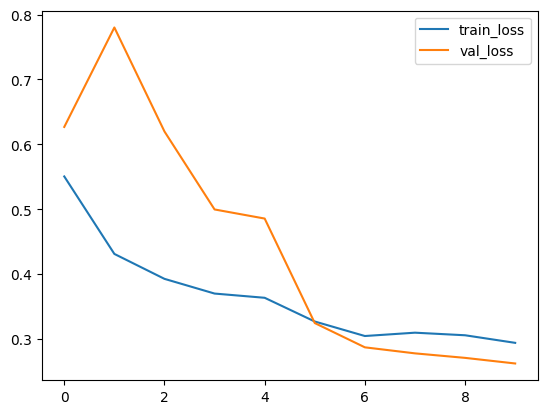

In [8]:
import mlflow

client = mlflow.tracking.MlflowClient()
run_id = logger.run_id

# Récupérer les métriques
metrics = client.get_metric_history(run_id, "train_loss")
train_loss = [m.value for m in metrics]

metrics = client.get_metric_history(run_id, "val_loss")
val_loss = [m.value for m in metrics]

# Tracer avec pandas
pd.DataFrame({"train_loss": train_loss, "val_loss": val_loss}).plot()

## Évaluer sur l'ensemble de test

Une fois l'entraînement terminé, nous pouvons évaluer le modèle sur la **division de test réservée**.  
Cela exécute la boucle `test` de Lightning, qui utilise le `test_dataloader` défini dans le DataModule.

In [ ]:
# Exécuter l'évaluation sur l'ensemble de test (défini par le csv_datamodule)
trainer.test(
    model,
    datamodule=dm,
    ckpt_path=trainer.checkpoint_callback.best_model_path,
    weights_only=False
)

## Visualiser les artefacts de prédiction

Pendant les tests, le modèle a enregistré ses masques de prédiction sous forme de PNG dans le **dossier des artefacts MLflow**.  
Ici nous :

1. Localisons le bon dossier expérience/exécution sous `./logs/mlrun/`  
2. Chargeons récursivement les fichiers PNG produits pendant l'étape de test  
3. Affichons quelques prédictions côte à côte pour une vérification qualitative rapide  

> Astuce : dans vos propres expériences, vous pouvez ajuster le nombre d'échantillons enregistrés pendant la validation/test  
> en modifiant le paramètre `max_samples` lors de l'instanciation du modèle.

Experiment: 821392128880821075 Run: e7da2fd1e7fc47fc978c110d1daf6d45
Artifact dir: logs\mlrun\821392128880821075\e7da2fd1e7fc47fc978c110d1daf6d45\artifacts\test
Found 4 images under logs\mlrun\821392128880821075\e7da2fd1e7fc47fc978c110d1daf6d45\artifacts\test


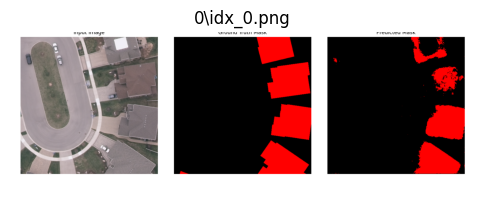

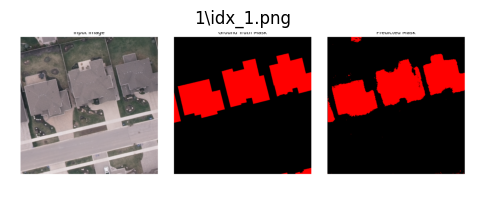

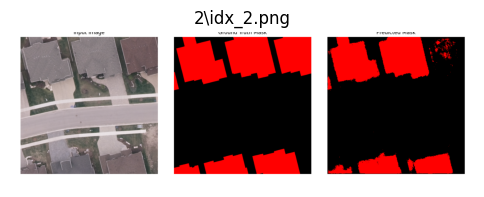

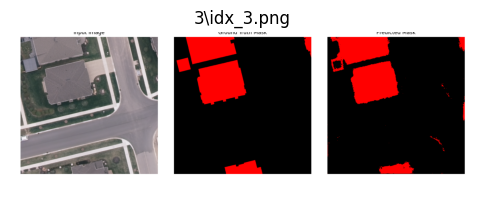

In [ ]:
# Identifier les ids d'expérience/exécution MLflow
print("Experiment:", logger.experiment_id, "Run:", logger.run_id)
experiment_id = logger.experiment_id
run_id = logger.run_id

# Chemin vers les artefacts produits pendant la boucle de test
artifact_dir = Path("./logs/mlrun") / str(experiment_id) / str(run_id) / "artifacts" / "test"
print("Artifact dir:", artifact_dir)

# Trouver les PNG de prédiction
img_files = sorted(artifact_dir.rglob("*.png"))
print(f"Found {len(img_files)} images under {artifact_dir}")

# Afficher les premières prédictions
for img_file in img_files[:8]:
    img = Image.open(img_file)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(str(img_file.relative_to(artifact_dir)))
    plt.axis("off")
    plt.show()

## Utiliser la CLI avec un fichier de configuration pour entraîner un modèle

Comme mentionné au début du tutoriel, bien que nous ayons configuré manuellement le Trainer ici, nous pourrions faire de même en utilisant un fichier de configuration.

J'ai préparé [le fichier de configuration](TrainConfig.yaml) qui agirait de manière similaire à la façon dont nous avons tout configuré ci-dessus.

J'ai également adapté [le script d'entraînement](train.py) qui nécessitait quelques ajustements en raison de notre version torch.

Ensuite, nous pouvons exécuter le script d'entraînement comme suit :

    (tutorial) path/to/geoai_learningTutorial7> python train.py fit --config ./TrainConfig.yaml

### Voici ce qui sera vu en ligne de commande :

    Seed set to 42
    Seed set to 42
    
    LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
    
        ┏━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
        ┃   ┃ Name                 ┃ Type                 ┃ Params ┃ Mode  ┃ FLOPs ┃
        ┡━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
        │ 0 │ loss                 │ SoftCrossEntropyLoss │      0 │ train │     0 │
        │ 1 │ iou_metric           │ MeanIoU              │      0 │ train │     0 │
        │ 2 │ iou_classwise_metric │ ClasswiseWrapper     │      0 │ train │     0 │
        │ 3 │ model                │ UnetPlusPlus         │ 26.1 M │ train │     0 │
        └───┴──────────────────────┴──────────────────────┴────────┴───────┴───────┘
    
    Trainable params: 26.1 M
    Non-trainable params: 0
    Total params: 26.1 M
    Total estimated model params size (MB): 104
    Modules in train mode: 269
    Modules in eval mode: 0
    Total FLOPs: 0
    
    Epoch 9/9  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 0:00:02 • 0:00:00 3.13it/s v_num: f65c val_meaniou_background:
                                                                                     0.967 val_meaniou_buildings: 0.743
                                                                                     val_loss: 0.257
                                                                                     train_meaniou_background: 0.950
                                                                                     train_meaniou_buildings: 0.718
                                                                                     train_loss: 0.279
    GPU available: True (cuda), used: True
    TPU available: False, using: 0 TPU cores
    
    Restoring states from the checkpoint path at ./logs/mlrun\821392128880821075\565b5db4b55940e8be9e221f7948f65c\checkpoints\model-epoch=08-val_loss=0.257.ckpt
    
    LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
    Loaded model weights from the checkpoint at ./logs/mlrun\821392128880821075\565b5db4b55940e8be9e221f7948f65c\checkpoints\model-epoch=08-val_loss=0.257.ckpt
    
    ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
    ┃        Test metric        ┃       DataLoader 0        ┃
    ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
    │         test_loss         │    0.2717406749725342     │
    │  test_meaniou_background  │    0.9564436674118042     │
    │  test_meaniou_buildings   │    0.8630046844482422     │
    └───────────────────────────┴───────────────────────────┘